In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.spatial import KDTree
from collections import deque

# Constants for point types
E = 100.0       # Large positive input for uncleaned areas
NEG_E = -100.0  # Large negative input for obstacles
CLEANED = 0.0   # Indicates a cleaned point
MU = 0.5        # Weight factor for neural connections
C = 1.0         # Direction preference weight

# Define the point structure
class Point:
    def __init__(self, x, y, z, point_type=E):
        self.x = x
        self.y = y
        self.z = z
        self.type = point_type  # Either E (normal), NEG_E (obstacle), or CLEANED
        self.neighbors = []

def generate_points(n, space_size):
    points = [Point(*coords) for coords in np.random.rand(n, 3) * space_size]
    
    # Assign some points as obstacles (10% of points)
    num_obstacles = max(1, n // 10)
    obstacle_indices = np.random.choice(n, size=num_obstacles, replace=False)
    for idx in obstacle_indices:
        points[idx].type = NEG_E
    
    return points

def build_kdtree(points):
    coords = np.array([[p.x, p.y, p.z] for p in points])
    tree = KDTree(coords)
    
    for i, p in enumerate(points):
        _, indices = tree.query([coords[i]], k=min(20, len(points)))  # Get 20 nearest neighbors
        p.neighbors = indices[0].tolist()
    
    return points

def distance(point1, point2):
    """Computes the Euclidean distance between two points."""
    return np.sqrt((point2.x - point1.x) ** 2 + (point2.y - point1.y) ** 2 + (point2.z - point1.z) ** 2)

def is_neighbour(tree_nodes):
    """
    Identifies valid neighbors within a given radius.
    Filters the precomputed 20 neighbors to retain only those within range.
    """
    R = 44.8  # Threshold radius in inches
    queue = deque([0])  # Start BFS from the first node
    visited = set()
    filtered_map = {}  # Store neighbors for each node

    while queue:
        node_idx = queue.popleft()
        if node_idx in visited:
            continue

        visited.add(node_idx)
        node = tree_nodes[node_idx]
        valid_neighbors = []
    
        for neighbor_idx in node.neighbors:
            neighbor = tree_nodes[neighbor_idx]
            if distance(node, neighbor) <= R:
                valid_neighbors.append(neighbor_idx)

        filtered_map[node_idx] = valid_neighbors

        for neighbor_idx in valid_neighbors:
            if neighbor_idx not in visited:
                queue.append(neighbor_idx)
    
    return filtered_map

def fit_plane_least_squares(point, points):
    """
    Fits a plane using the least squares method for a given point's neighbors.
    Returns the normal vector and distance to the plane.
    """
    if not point.neighbors:
        return None, None  # No neighbors, cannot fit plane
    
    # Extract neighbor coordinates
    A = np.array([[points[i].x, points[i].y, points[i].z] for i in point.neighbors])
    b = -np.ones((A.shape[0], 1))  # Vector of -1s
    
    # Solve for normal vector using least squares (n = (A^T A)^-1 A^T b)
    n_i, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    n_i = n_i.flatten()
    
    # Compute distance to the plane
    q_i = np.array([point.x, point.y, point.z])
    d_i = abs(np.dot(n_i, q_i) + 1) / np.linalg.norm(n_i)
    
    return n_i, d_i

def compute_turn_angle(q_current, q_prev, q_prev_prev):
    """Calculates the angle change between two movement directions."""
    v1 = q_current - q_prev
    v2 = q_prev - q_prev_prev
    if np.linalg.norm(v1) == 0 or np.linalg.norm(v2) == 0:
        return 0
    cos_theta = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    return theta / np.pi  # Normalize to [0,1]

def choose_next_location(current_idx, prev_idx, prev_prev_idx, x_array, points, connections):
    """Selects the next location using neural activity and movement direction preference."""
    neighbors = connections[current_idx]
    if not neighbors:
        return None  # No available neighbors (dead end)
    
    best_idx = None
    best_val = -np.inf
    for j in neighbors:
        x_j = x_array[j]
        if prev_idx is not None and prev_prev_idx is not None:
            y_j = 1 - compute_turn_angle(np.array([points[j].x, points[j].y, points[j].z]),
                                         np.array([points[prev_idx].x, points[prev_idx].y, points[prev_idx].z]),
                                         np.array([points[prev_prev_idx].x, points[prev_prev_idx].y, points[prev_prev_idx].z]))
        else:
            y_j = 1  # First movement, no angle to consider
        score = x_j + C * y_j
        if score > best_val:
            best_val = score
            best_idx = j
    
    return best_idx


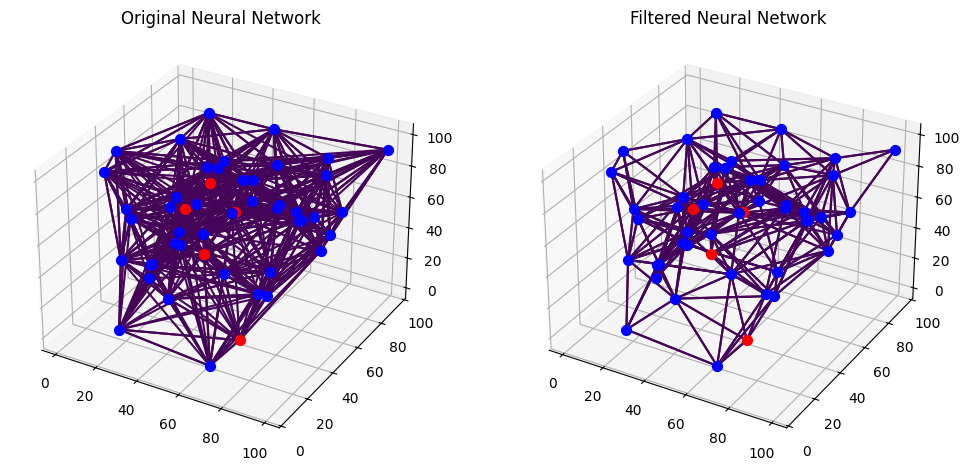

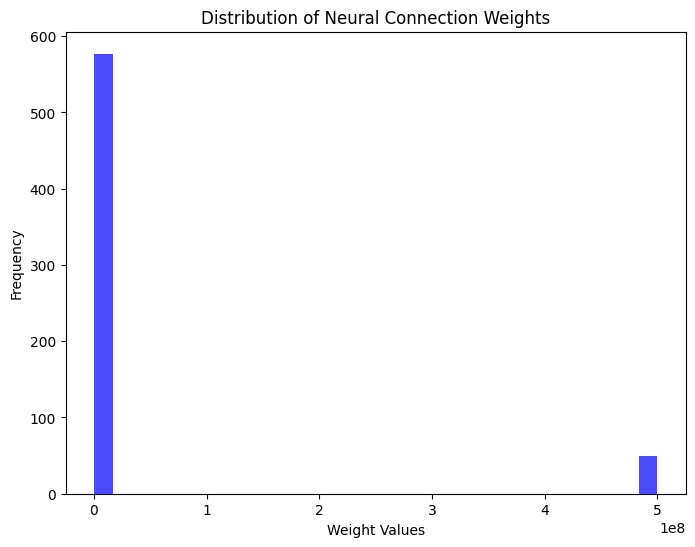

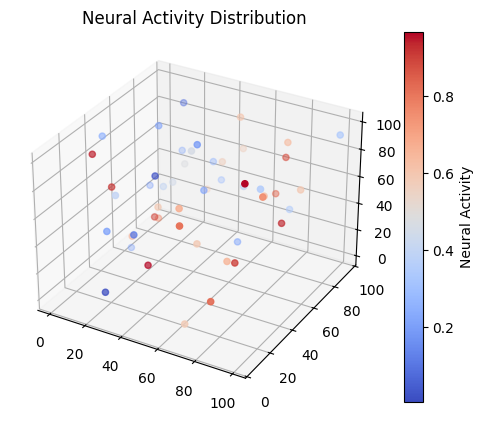

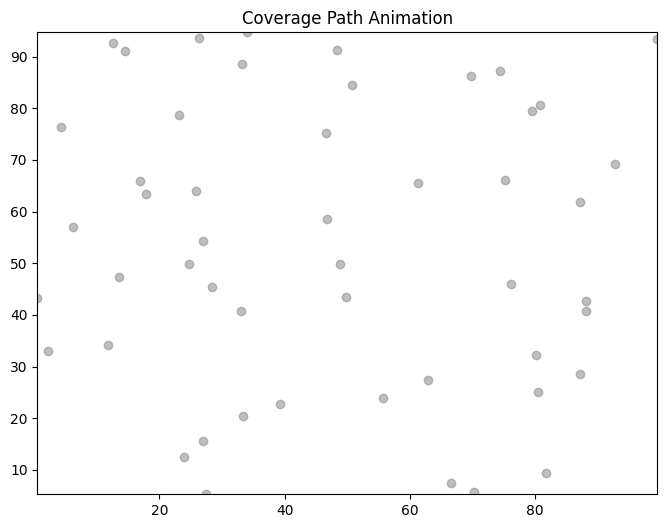

C:\Users\Rodrigo\AppData\Roaming\Python\Python312\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [2]:
def plot_neural_network(points, connections, title, ax):
    epsilon = 1e-9  # Small constant to prevent division by zero
    for i, p in enumerate(points):
        ax.scatter(p.x, p.y, p.z, color='b' if p.type != NEG_E else 'r', s=50)
        for neighbor_idx in connections[i]:
            neighbor = points[neighbor_idx]
            weight = MU / (distance(p, neighbor) + epsilon)
            ax.plot([p.x, neighbor.x], [p.y, neighbor.y], [p.z, neighbor.z], color=plt.cm.viridis(weight))
    ax.set_title(title)

def visualize_weight_distribution(points, connections):
    """Plots a heatmap of connection weights."""
    plt.figure(figsize=(8, 6))
    weights = [MU / (distance(points[i], points[j]) + 1e-9) for i in connections for j in connections[i]]
    plt.hist(weights, bins=30, color='blue', alpha=0.7)
    plt.xlabel("Weight Values")
    plt.ylabel("Frequency")
    plt.title("Distribution of Neural Connection Weights")
    plt.show()

def visualize_neural_activity(points, x_values):
    """Plots neural activity values for each neuron."""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    sc = ax.scatter([p.x for p in points],
                    [p.y for p in points],
                    [p.z for p in points],
                    c=x_values, cmap='coolwarm', marker='o')
    plt.colorbar(sc, label='Neural Activity')
    plt.title("Neural Activity Distribution")
    plt.show()

def animate_coverage(points, coverage_path):
    """Animates the coverage process over time."""
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_xlim(min(p.x for p in points), max(p.x for p in points))
    ax.set_ylim(min(p.y for p in points), max(p.y for p in points))
    
    scat = ax.scatter([p.x for p in points], [p.y for p in points], color='gray', alpha=0.5)
    path_line, = ax.plot([], [], 'r-', linewidth=2)
    
    def update(frame):
        path = coverage_path[:frame]
        path_line.set_data([points[i].x for i in path],
                           [points[i].y for i in path])
        return path_line,
    
    ani = animation.FuncAnimation(fig, update, frames=len(coverage_path), interval=200, repeat=False)
    plt.title("Coverage Path Animation")
    plt.show()

def test_full_system():
    num_points = 50
    space_size = 100
    points = generate_points(num_points, space_size)
    points = build_kdtree(points)
    original_connections = {i: p.neighbors for i, p in enumerate(points)}
    filtered_connections = is_neighbour(points)
    x_values = np.random.rand(len(points))  # Simulating neural activity
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': '3d'})
    plot_neural_network(points, original_connections, "Original Neural Network", axes[0])
    plot_neural_network(points, filtered_connections, "Filtered Neural Network", axes[1])
    plt.show()
    
    visualize_weight_distribution(points, filtered_connections)
    visualize_neural_activity(points, x_values)
    
    coverage_path = list(range(len(points)))  # Simulated path for testing
    animate_coverage(points, coverage_path)

test_full_system()